# SleepFM LOO-CL Tail Metric 분석 워크스루

이 노트북은 `260414_LOO-CL 분석 1.md`를 바탕으로 진행한 **2차 geometry audit**를 차례대로 다시 읽기 위한 안내서다.

이번 단계의 핵심은 기존 `consensus / alignment / jackknife` 평균 요약만 보는 데서 멈추지 않고, 아래를 추가로 정량화한 것이다.

1. `split score`: 4개 modality가 `2+2` subgroup으로 갈라지는 정도
2. `outlier score`: `3+1` 형태로 한 modality가 튀는 정도
3. `p05 / p95 / top-k` 기반 subject summary
4. `unstable_window_fraction`: unstable tail에 들어가는 window 비율
5. 이 새 지표들을 downstream diagnosis error와 다시 join한 결과

읽는 순서는 아래처럼 잡았다.

1. 어떤 artifact를 읽는지 확인
2. 전체 SHHS geometry summary 읽기
3. dataset-level split / outlier 분포 확인
4. subject-level tail summary 확인
5. downstream error type과 새 metric을 다시 비교
6. correlation과 figure를 읽고 해석
7. 이번 단계에서 무엇이 더 설명되고, 무엇이 아직 남는지 정리


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

AUDIT_DIR = ROOT / 'artifacts' / 'audit' / 'loo_geometry_model_base_paperexact_shhs'
DIAG_DIR = AUDIT_DIR / 'diagnosis_6y'

PATHS = {
    'geometry_summary': AUDIT_DIR / 'summary.json',
    'subject_metrics': AUDIT_DIR / 'subject_metrics.csv',
    'window_metrics': AUDIT_DIR / 'window_metrics.csv',
    'diagnosis_summary': DIAG_DIR / 'diagnosis_geometry_summary.json',
    'target_error_summary': DIAG_DIR / 'target_error_summary.csv',
    'target_metric_correlation': DIAG_DIR / 'target_metric_correlation.csv',
    'scatter_grid': DIAG_DIR / 'scatter_grid_6y.png',
    'tail_boxplots': DIAG_DIR / 'chf_tail_boxplots_6y.png',
    'tail_risk_scatter': DIAG_DIR / 'chf_risk_rank_vs_tail_metrics_6y.png',
    'split_outlier_scatter': DIAG_DIR / 'chf_split_vs_outlier_6y.png',
    'constellations': DIAG_DIR / 'chf_example_constellations.png',
}

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)
pd.set_option('display.max_colwidth', 160)

for name, path in PATHS.items():
    print(f'{name:>24}: {path} | exists={path.exists()}')

def show_image(key: str, width: int | None = None):
    display(Image(filename=str(PATHS[key]), width=width))


        geometry_summary: C:\Projects\aiot\sleepfm-repro\artifacts\audit\loo_geometry_model_base_paperexact_shhs\summary.json | exists=True
         subject_metrics: C:\Projects\aiot\sleepfm-repro\artifacts\audit\loo_geometry_model_base_paperexact_shhs\subject_metrics.csv | exists=True
          window_metrics: C:\Projects\aiot\sleepfm-repro\artifacts\audit\loo_geometry_model_base_paperexact_shhs\window_metrics.csv | exists=True
       diagnosis_summary: C:\Projects\aiot\sleepfm-repro\artifacts\audit\loo_geometry_model_base_paperexact_shhs\diagnosis_6y\diagnosis_geometry_summary.json | exists=True
    target_error_summary: C:\Projects\aiot\sleepfm-repro\artifacts\audit\loo_geometry_model_base_paperexact_shhs\diagnosis_6y\target_error_summary.csv | exists=True
target_metric_correlation: C:\Projects\aiot\sleepfm-repro\artifacts\audit\loo_geometry_model_base_paperexact_shhs\diagnosis_6y\target_metric_correlation.csv | exists=True
            scatter_grid: C:\Projects\aiot\sleepfm-repro\ar

## 1. 이번 단계에서 실제로 추가된 것

이번 단계는 `mean-based metric`의 한계를 줄이기 위한 보강 단계다.

- `split score`
  - 가능한 `2+2` partition을 모두 훑고 `within-group cosine - between-group cosine`이 가장 큰 값을 잡는다.
  - 값이 크면 `BAS/RESP`와 `EKG/EMG`처럼 두 subgroup이 갈라져 있다는 뜻이다.
- `outlier score`
  - 3개 modality는 서로 잘 모이는데 1개만 다른 쪽으로 튀는 `3+1` failure mode를 잡는다.
- tail-aware subject summary
  - `alignment_mean_p05`, `jackknife_instability_p95`, `split_score_p95`, `outlier_score_p95`처럼 평균보다 tail을 더 직접 반영하는 요약을 추가했다.
- `unstable_window_fraction`
  - dataset-level quantile threshold를 기준으로 unstable tail에 들어가는 window 비율을 subject마다 계산했다.

즉 이번 단계의 목적은 다음 한 문장으로 요약된다.

> case study에서 보인 `2+2 split`, `3+1 outlier`, `unstable tail`을 전체 데이터와 downstream error table 위에서 다시 정량화한다.


In [2]:
artifact_df = pd.DataFrame(
    {
        'artifact': list(PATHS.keys()),
        'path': [str(path) for path in PATHS.values()],
        'exists': [path.exists() for path in PATHS.values()],
    }
)
display(artifact_df)


,artifact,path,exists
0,geometry_summary,C:\Projects\aiot\sleepfm-repro\artifacts\audit\loo_geometry_model_base_paperexact_shhs\summary.json,True
1,subject_metrics,C:\Projects\aiot\sleepfm-repro\artifacts\audit\loo_geometry_model_base_paperexact_shhs\subject_metrics.csv,True
2,window_metrics,C:\Projects\aiot\sleepfm-repro\artifacts\audit\loo_geometry_model_base_paperexact_shhs\window_metrics.csv,True
3,diagnosis_summary,C:\Projects\aiot\sleepfm-repro\artifacts\audit\loo_geometry_model_base_paperexact_shhs\diagnosis_6y\diagnosis_geometry_summary.json,True
4,target_error_summary,C:\Projects\aiot\sleepfm-repro\artifacts\audit\loo_geometry_model_base_paperexact_shhs\diagnosis_6y\target_error_summary.csv,True
5,target_metric_correlation,C:\Projects\aiot\sleepfm-repro\artifacts\audit\loo_geometry_model_base_paperexact_shhs\diagnosis_6y\target_metric_correlation.csv,True
6,scatter_grid,C:\Projects\aiot\sleepfm-repro\artifacts\audit\loo_geometry_model_base_paperexact_shhs\diagnosis_6y\scatter_grid_6y.png,True
7,tail_boxplots,C:\Projects\aiot\sleepfm-repro\artifacts\audit\loo_geometry_model_base_paperexact_shhs\diagnosis_6y\chf_tail_boxplots_6y.png,True
8,tail_risk_scatter,C:\Projects\aiot\sleepfm-repro\artifacts\audit\loo_geometry_model_base_paperexact_shhs\diagnosis_6y\chf_risk_rank_vs_tail_metrics_6y.png,True
9,split_outlier_scatter,C:\Projects\aiot\sleepfm-repro\artifacts\audit\loo_geometry_model_base_paperexact_shhs\diagnosis_6y\chf_split_vs_outlier_6y.png,True


## 2. geometry summary 다시 읽기

먼저 전체 SHHS geometry summary를 다시 읽는다. 여기서는 기존 평균 지표가 그대로 유지되는지, 그리고 새로 추가한 `split / outlier / threshold`가 어떤 값으로 잡혔는지 본다.


In [3]:
geometry_summary = json.loads(PATHS['geometry_summary'].read_text(encoding='utf-8'))
diagnosis_summary = json.loads(PATHS['diagnosis_summary'].read_text(encoding='utf-8'))
subject_df = pd.read_csv(PATHS['subject_metrics'])
error_df = pd.read_csv(PATHS['target_error_summary'])
corr_df = pd.read_csv(PATHS['target_metric_correlation'])

headline = pd.DataFrame(
    [
        ('n_subjects', geometry_summary['n_subjects']),
        ('n_windows_total', geometry_summary['n_windows_total']),
        ('alignment_mean_dataset', geometry_summary['alignment_mean_dataset']),
        ('consensus_norm_mean_dataset', geometry_summary['consensus_norm_mean_dataset']),
        ('loo_mean_norm_mean_dataset', geometry_summary['loo_mean_norm_mean_dataset']),
        ('jackknife_instability_mean_dataset', geometry_summary['jackknife_instability_mean_dataset']),
        ('split_score_mean_dataset', geometry_summary['split_score_mean_dataset']),
        ('outlier_score_mean_dataset', geometry_summary['outlier_score_mean_dataset']),
    ],
    columns=['metric', 'value'],
)
display(headline)

threshold_df = pd.DataFrame(
    geometry_summary['thresholds'].items(),
    columns=['threshold_name', 'value'],
)
display(threshold_df)


,metric,value
0,n_subjects,5787.000000
1,n_windows_total,582153.000000
2,alignment_mean_dataset,0.626525
3,consensus_norm_mean_dataset,0.797188
4,loo_mean_norm_mean_dataset,0.822051
5,jackknife_instability_mean_dataset,0.078905
6,split_score_mean_dataset,0.222953
7,outlier_score_mean_dataset,0.105109


,threshold_name,value
0,consensus_norm_low,0.757508
1,alignment_mean_low,0.549945
2,jackknife_instability_high,0.097422
3,split_score_high,0.321913
4,outlier_score_high,0.189923


### geometry summary 해석

기존 평균 geometry는 바뀌지 않았다. 즉 이번 단계는 기존 audit를 뒤집는 것이 아니라, **같은 latent audit를 더 tail-aware하게 확장한 것**이다.

여기서 새로 읽어야 할 값은 아래다.

- `split_score_mean_dataset`
  - 평균적으로 `2+2 split` 방향의 분리가 얼마나 있는지
- `outlier_score_mean_dataset`
  - 평균적으로 `3+1 outlier` 형태가 얼마나 있는지
- `thresholds`
  - 이후 `unstable_window_fraction`을 정의하는 dataset-level 기준점


## 3. dataset-level split / outlier pattern

이제 이번 단계의 가장 직접적인 질문을 본다.

> 전체 SHHS latent에서 실제로 어떤 split pattern이 가장 자주 나타나는가?

그리고

> 어떤 modality가 가장 자주 outlier처럼 보이는가?


,partition,fraction
0,BAS+RESP|EKG+EMG,0.989484
1,BAS+EKG|RESP+EMG,0.007953
2,BAS+EMG|RESP+EKG,0.002563


,outlier_modality,fraction
0,BAS,0.588182
1,EKG,0.259760
2,RESP,0.116105
3,EMG,0.035953


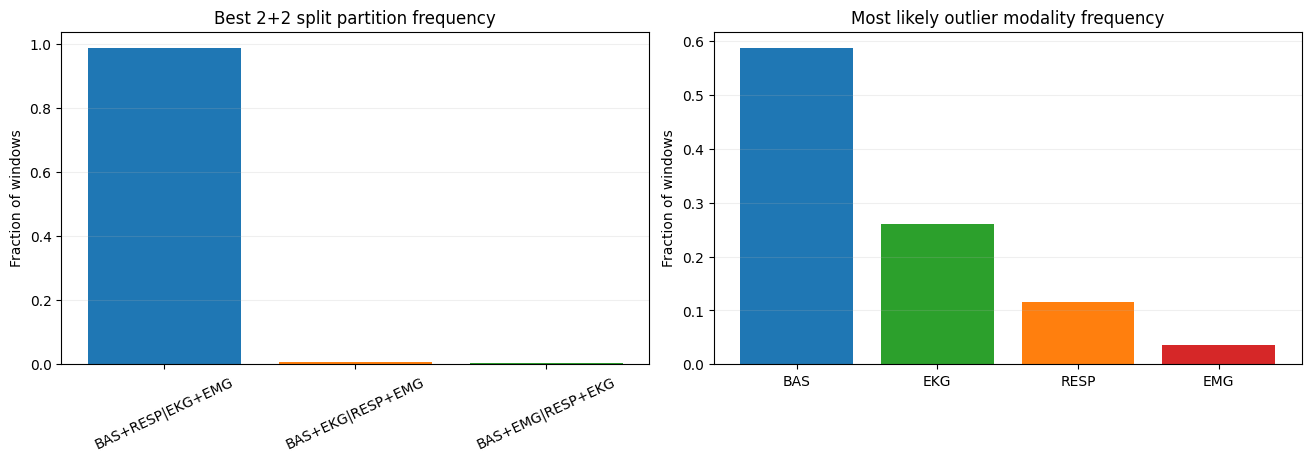

In [4]:
split_df = (
    pd.DataFrame(
        geometry_summary['best_split_partition_fraction_dataset'].items(),
        columns=['partition', 'fraction'],
    )
    .sort_values('fraction', ascending=False)
    .reset_index(drop=True)
)
outlier_df = (
    pd.DataFrame(
        geometry_summary['outlier_modality_fraction_dataset'].items(),
        columns=['outlier_modality', 'fraction'],
    )
    .sort_values('fraction', ascending=False)
    .reset_index(drop=True)
)

display(split_df)
display(outlier_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
axes[0].bar(split_df['partition'], split_df['fraction'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_title('Best 2+2 split partition frequency')
axes[0].set_ylabel('Fraction of windows')
axes[0].tick_params(axis='x', rotation=25)
axes[0].grid(axis='y', alpha=0.2)

axes[1].bar(outlier_df['outlier_modality'], outlier_df['fraction'], color=['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728'])
axes[1].set_title('Most likely outlier modality frequency')
axes[1].set_ylabel('Fraction of windows')
axes[1].grid(axis='y', alpha=0.2)
plt.show()


### dataset-level split / outlier 해석

이번 단계의 가장 중요한 한 줄은 아래다.

- best split partition의 거의 대부분이 `BAS+RESP | EKG+EMG`
- outlier modality는 `BAS`가 가장 많고, 그 다음이 `EKG`

즉 case study에서 봤던 `cardio-respiratory vs electrophysiology` 비슷한 분리 방향이 특정 예시 몇 개의 우연이 아니라, **전체 SHHS window-level geometry에서 가장 자주 등장하는 split 방향**으로 잡힌다.


## 4. subject-level tail summary

이제 window-level metric을 subject-level로 어떻게 요약했는지 본다. 이번 단계에서는 `mean`만 보지 않고 아래를 같이 본다.

- `alignment_mean_p05`
- `jackknife_instability_p95`
- `split_score_p95`
- `outlier_score_p95`
- `unstable_window_fraction`

이 지표들은 `평균적으로 괜찮은 subject` 안에 숨어 있는 `critical unstable segment`를 더 직접 반영하려는 목적을 가진다.


,count,mean,std,min,50%,75%,90%,95%,99%,max
alignment_mean_p05,5787.0,0.572693,0.033318,0.419351,0.577833,0.596399,0.610568,0.618107,0.631180,0.681336
jackknife_instability_p95,5787.0,0.091800,0.008332,0.066117,0.090483,0.096402,0.102841,0.107886,0.117196,0.131349
split_score_p95,5787.0,0.296448,0.042954,0.126335,0.292499,0.317786,0.348571,0.375545,0.430084,0.530380
outlier_score_p95,5787.0,0.175154,0.034479,0.096116,0.169775,0.192647,0.219827,0.239631,0.280696,0.436107
unstable_window_fraction,5787.0,0.138779,0.158909,0.000000,0.076190,0.188679,0.358907,0.494988,0.722772,0.933333


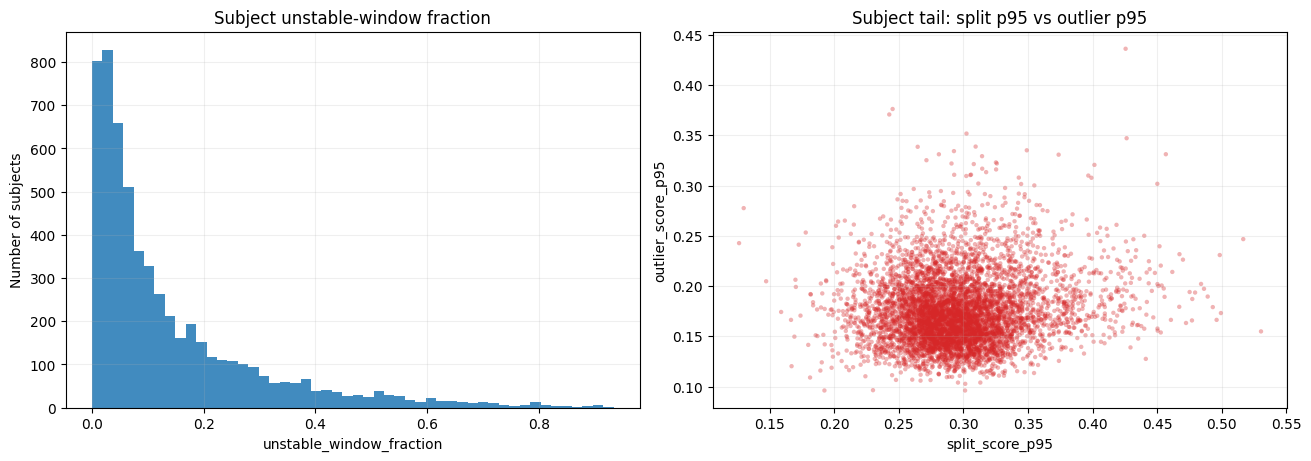

In [5]:
tail_metric_cols = [
    'alignment_mean_p05',
    'jackknife_instability_p95',
    'split_score_p95',
    'outlier_score_p95',
    'unstable_window_fraction',
]

subject_tail_summary = subject_df[tail_metric_cols].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]).T
display(subject_tail_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
axes[0].hist(subject_df['unstable_window_fraction'], bins=50, color='#1f77b4', alpha=0.85)
axes[0].set_title('Subject unstable-window fraction')
axes[0].set_xlabel('unstable_window_fraction')
axes[0].set_ylabel('Number of subjects')
axes[0].grid(alpha=0.2)

axes[1].scatter(
    subject_df['split_score_p95'],
    subject_df['outlier_score_p95'],
    s=10,
    alpha=0.35,
    color='#d62728',
    edgecolors='none',
)
axes[1].set_title('Subject tail: split p95 vs outlier p95')
axes[1].set_xlabel('split_score_p95')
axes[1].set_ylabel('outlier_score_p95')
axes[1].grid(alpha=0.2)
plt.show()


In [6]:
top_unstable_subjects = subject_df.sort_values(
    ['unstable_window_fraction', 'split_score_p95', 'jackknife_instability_p95'],
    ascending=False,
)[[
    'subject',
    'n_windows',
    'unstable_window_fraction',
    'alignment_mean_p05',
    'jackknife_instability_p95',
    'split_score_p95',
    'outlier_score_p95',
    'dominant_best_split_partition',
    'dominant_outlier_modality',
]].head(12)
display(top_unstable_subjects)

dominant_split = subject_df['dominant_best_split_partition'].value_counts(normalize=True).rename('fraction').to_frame()
dominant_outlier = subject_df['dominant_outlier_modality'].value_counts(normalize=True).rename('fraction').to_frame()
display(dominant_split)
display(dominant_outlier)


,subject,n_windows,unstable_window_fraction,alignment_mean_p05,jackknife_instability_p95,split_score_p95,outlier_score_p95,dominant_best_split_partition,dominant_outlier_modality
2269,shhs1-202277,90,0.933333,0.531594,0.099877,0.452784,0.220353,BAS+RESP|EKG+EMG,BAS
3314,shhs1-203325,105,0.914286,0.681336,0.066117,0.271383,0.325211,BAS+RESP|EKG+EMG,RESP
2353,shhs1-202363,89,0.910112,0.447483,0.123021,0.320063,0.217910,BAS+RESP|EKG+EMG,EKG
4657,shhs1-204670,95,0.905263,0.544564,0.094858,0.489098,0.189576,BAS+RESP|EKG+EMG,BAS
1537,shhs1-201542,105,0.904762,0.419351,0.131349,0.286431,0.183993,BAS+RESP|EKG+EMG,BAS
4834,shhs1-204852,106,0.896226,0.483869,0.113374,0.477181,0.187142,BAS+RESP|EKG+EMG,BAS
1510,shhs1-201515,105,0.895238,0.573604,0.089352,0.433196,0.228932,BAS+RESP|EKG+EMG,BAS
3362,shhs1-203373,105,0.885714,0.461238,0.119445,0.277890,0.160587,BAS+RESP|EKG+EMG,BAS
3336,shhs1-203347,96,0.885417,0.437228,0.126355,0.266436,0.244227,BAS+RESP|EKG+EMG,EMG
1754,shhs1-201760,108,0.870370,0.557503,0.091434,0.530380,0.154903,BAS+RESP|EKG+EMG,BAS


,fraction
dominant_best_split_partition,
BAS+RESP|EKG+EMG,0.999654
BAS+EKG|RESP+EMG,0.000173
BAS+EMG|RESP+EKG,0.000173


,fraction
dominant_outlier_modality,
BAS,0.742354
EKG,0.210299
RESP,0.030759
EMG,0.016589


### subject-level tail 해석

여기서 봐야 할 포인트는 두 가지다.

- average subject는 비교적 안정적이지만, `unstable_window_fraction` 분포의 오른쪽 tail이 길다.
- 가장 불안정한 subject들은 동일한 dominant split pattern과 outlier modality를 반복적으로 보인다.

즉 unstable tail은 `몇 개 window의 우연한 이상치`라기보다, **특정 subject 안에서 반복되는 구조적 패턴**일 가능성이 높다.


## 5. downstream diagnosis 결과를 새 metric으로 다시 읽기

이제 가장 중요한 질문으로 넘어간다.

> 새로 만든 tail-aware metric이 downstream error table에서 기존 mean metric보다 더 분리되는가?

먼저 target별 AUROC와 positive 수를 확인하고, 그 다음 `CHF`, `cvd_death`, `angina`를 예시로 error type table을 직접 본다.


In [7]:
target_rows = []
for target, info in diagnosis_summary['targets'].items():
    target_rows.append(
        {
            'target': target,
            'positive_within_horizon': info['positive_within_horizon'],
            'all_events': info['all_events'],
            'auroc': info['auroc'],
        }
    )

target_overview = pd.DataFrame(target_rows).sort_values('auroc', ascending=False).reset_index(drop=True)
display(target_overview)


,target,positive_within_horizon,all_events,auroc
0,cvd_death,58,123,0.866322
1,chf,113,203,0.841177
2,chd_death,38,82,0.838940
3,stroke,60,85,0.797131
4,mi,57,98,0.786088
5,angina,119,728,0.757366


In [8]:
focus_targets = ['chf', 'cvd_death', 'angina']
focus_metrics = [
    'count',
    'alignment_mean_p05',
    'jackknife_instability_p95',
    'split_score_p95',
    'outlier_score_p95',
    'unstable_window_fraction',
]

for target in focus_targets:
    display(Markdown(f'### {target}'))
    table = (
        error_df[error_df['target'] == target]
        .set_index('error_type')
        .loc[['TN', 'TP', 'FP', 'FN'], focus_metrics]
    )
    display(table)


### chf

,count,alignment_mean_p05,jackknife_instability_p95,split_score_p95,outlier_score_p95,unstable_window_fraction
error_type,,,,,,
TN,1812,0.571995,0.091981,0.294492,0.173736,0.135118
TP,38,0.557292,0.095502,0.317413,0.171471,0.207534
FP,75,0.565573,0.093460,0.307772,0.180148,0.192159
FN,75,0.571698,0.091898,0.305316,0.172284,0.158662


### cvd_death

,count,alignment_mean_p05,jackknife_instability_p95,split_score_p95,outlier_score_p95,unstable_window_fraction
error_type,,,,,,
TN,1895,0.571847,0.092010,0.294904,0.173903,0.137176
TP,11,0.560628,0.094709,0.314811,0.165662,0.179647
FP,47,0.553902,0.096446,0.316872,0.180021,0.230058
FN,47,0.576112,0.090759,0.307748,0.168677,0.133890


### angina

,count,alignment_mean_p05,jackknife_instability_p95,split_score_p95,outlier_score_p95,unstable_window_fraction
error_type,,,,,,
TN,1784,0.573308,0.091642,0.294960,0.172830,0.131259
TP,22,0.545788,0.098801,0.308954,0.175396,0.243773
FP,97,0.549394,0.097633,0.302168,0.194941,0.240624
FN,97,0.565439,0.093464,0.302545,0.171771,0.166603


In [9]:
delta_rows = []
for target in focus_targets:
    table = (
        error_df[error_df['target'] == target]
        .set_index('error_type')
        .loc[['TN', 'TP', 'FP', 'FN'], focus_metrics]
    )
    tn = table.loc['TN']
    for err in ['TP', 'FP', 'FN']:
        row = {'target': target, 'error_type': err}
        for metric in focus_metrics[1:]:
            row[metric] = table.loc[err, metric] - tn[metric]
        delta_rows.append(row)

delta_df = pd.DataFrame(delta_rows)
display(delta_df)


,target,error_type,alignment_mean_p05,jackknife_instability_p95,split_score_p95,outlier_score_p95,unstable_window_fraction
0,chf,TP,-0.014703,0.003522,0.022921,-0.002265,0.072417
1,chf,FP,-0.006422,0.001480,0.013280,0.006412,0.057041
2,chf,FN,-0.000297,-0.000083,0.010824,-0.001452,0.023545
3,cvd_death,TP,-0.011219,0.002699,0.019907,-0.008241,0.042471
4,cvd_death,FP,-0.017945,0.004435,0.021968,0.006118,0.092882
5,cvd_death,FN,0.004265,-0.001252,0.012844,-0.005226,-0.003286
6,angina,TP,-0.027520,0.007159,0.013994,0.002567,0.112514
7,angina,FP,-0.023914,0.005991,0.007208,0.022112,0.109365
8,angina,FN,-0.007869,0.001822,0.007585,-0.001059,0.035343


### downstream join 해석

이번 단계에서 가장 의미 있는 변화는 아래다.

- `split_score_p95`와 `unstable_window_fraction`은 여러 target에서 `FP`와 `TP`를 `TN`보다 더 불안정한 쪽으로 밀어 준다.
- 반면 `FN`은 항상 같은 방향으로 움직이지 않는다.

즉 이번 단계 결과는 아래처럼 읽는 것이 맞다.

> tail-aware metric은 `mean metric보다 더 잘 갈리는 부분`을 보여주지만, 아직 error 전체를 충분히 설명하는 수준은 아니다.


## 6. risk rank correlation

subject-level metric과 risk rank percentile의 상관도도 다시 본다. 이것은 `이 metric이 risk와 거의 같은 정보를 담는가, 아니면 별도의 failure signal인가`를 판단하는 데 도움을 준다.


target,angina,chd_death,chf,cvd_death,mi,stroke
metric,,,,,,
alignment_mean_p05,-0.076,0.014,0.026,0.017,0.085,0.057
jackknife_instability_p95,0.071,-0.020,-0.033,-0.024,-0.091,-0.063
split_score_p95,0.060,0.075,0.071,0.073,0.042,0.065
outlier_score_p95,0.044,-0.019,-0.023,-0.022,-0.038,-0.050
unstable_window_fraction,0.079,0.027,0.016,0.023,-0.032,-0.017


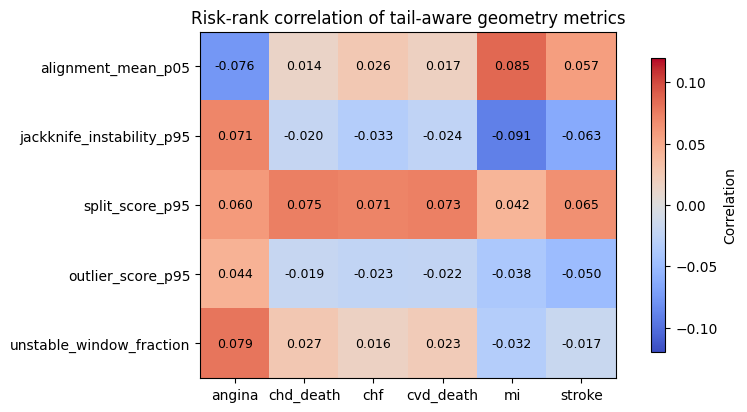

In [10]:
metric_order = [
    'alignment_mean_p05',
    'jackknife_instability_p95',
    'split_score_p95',
    'outlier_score_p95',
    'unstable_window_fraction',
]
corr_pivot = corr_df.pivot(index='metric', columns='target', values='correlation').loc[metric_order]
display(corr_pivot.round(3))

fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(corr_pivot.values, cmap='coolwarm', vmin=-0.12, vmax=0.12)
ax.set_xticks(range(len(corr_pivot.columns)), corr_pivot.columns)
ax.set_yticks(range(len(corr_pivot.index)), corr_pivot.index)
ax.set_title('Risk-rank correlation of tail-aware geometry metrics')
for i in range(corr_pivot.shape[0]):
    for j in range(corr_pivot.shape[1]):
        ax.text(j, i, f'{corr_pivot.iloc[i, j]:.3f}', ha='center', va='center', fontsize=9)
fig.colorbar(im, ax=ax, shrink=0.85, label='Correlation')
plt.show()


### correlation 해석

상관은 여전히 작다. 이것은 두 가지를 뜻한다.

- 좋은 쪽
  - 새 geometry metric은 단순히 `risk score의 다른 표현`은 아니다.
- 아직 부족한 쪽
  - subject-level summary만으로는 long-horizon disease risk/error를 강하게 설명하지 못한다.

즉 다음 단계가 `window metadata`, `stage transition`, `event density`, `prediction-critical window` 쪽으로 가야 한다는 문서의 방향과 잘 맞는다.


## 7. figure 읽기: tail-aware boxplots와 risk scatter

이번 단계에서 새로 만든 figure 두 장을 먼저 본다.

- `chf_tail_boxplots_6y.png`
  - CHF에서 `alignment p05`, `jackknife p95`, `split p95`, `outlier p95`를 error type별로 비교
- `chf_risk_rank_vs_tail_metrics_6y.png`
  - risk rank와 tail-aware geometry가 실제로 어떻게 퍼져 있는지 확인


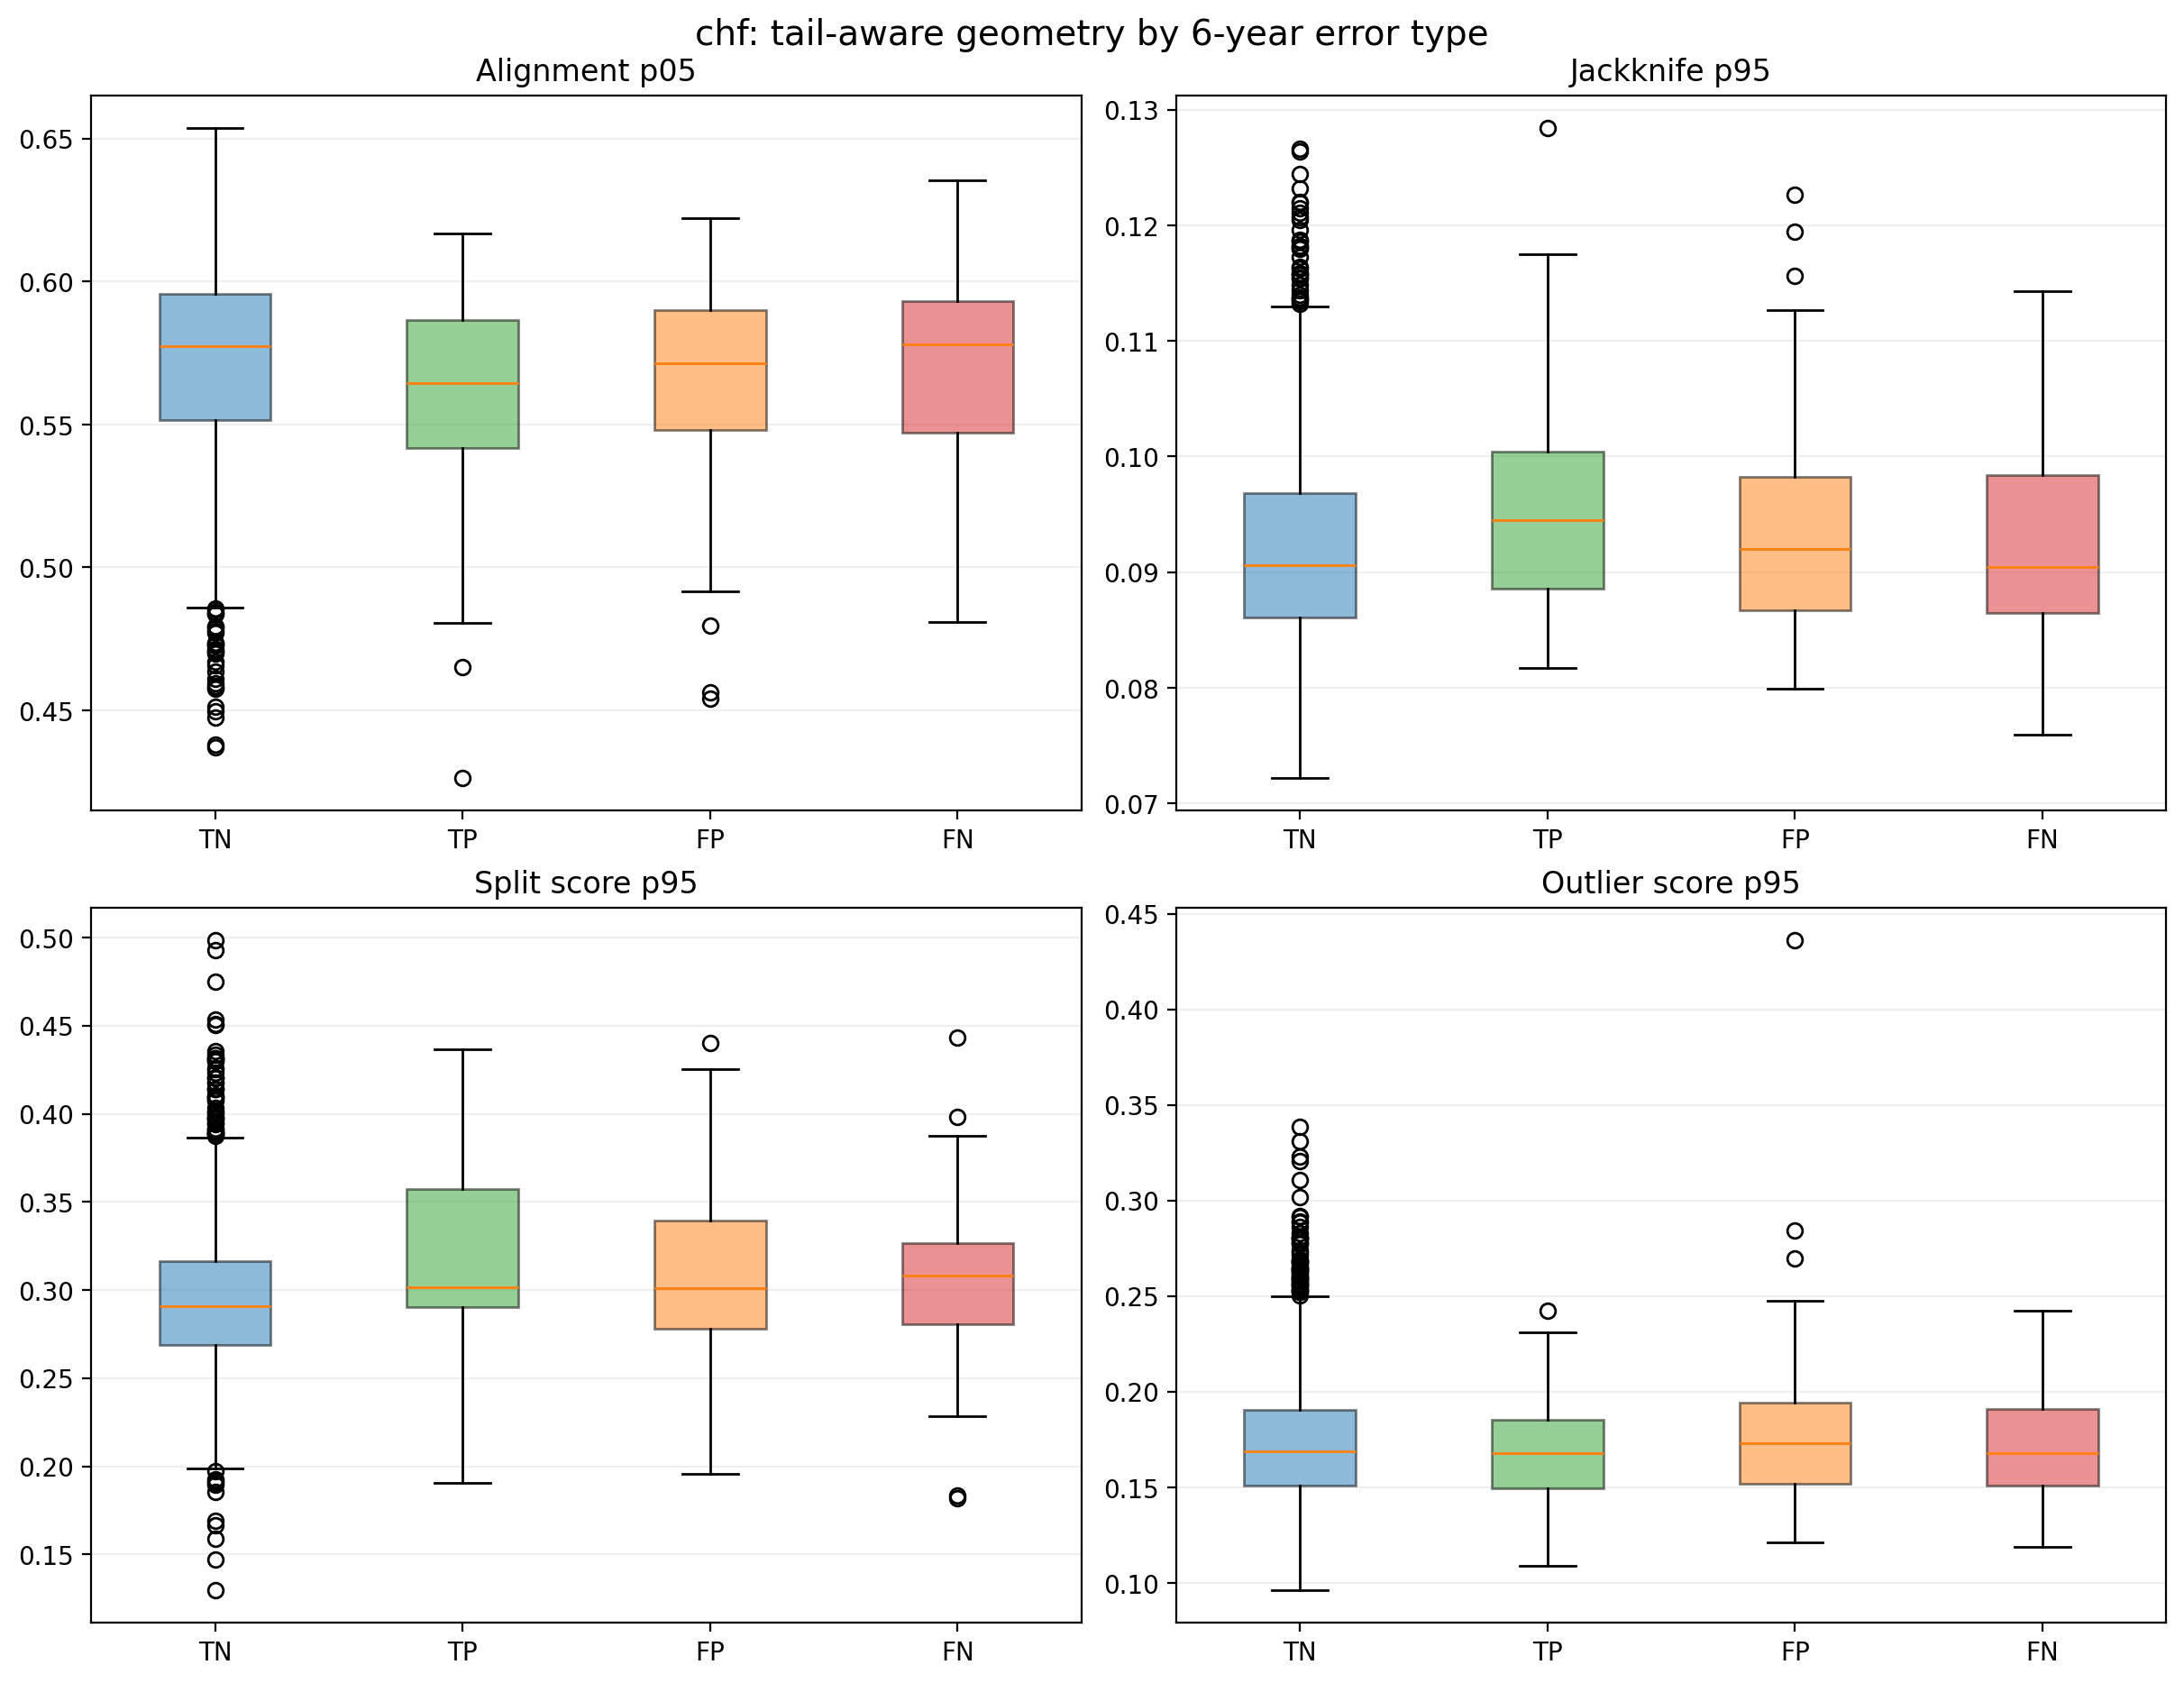

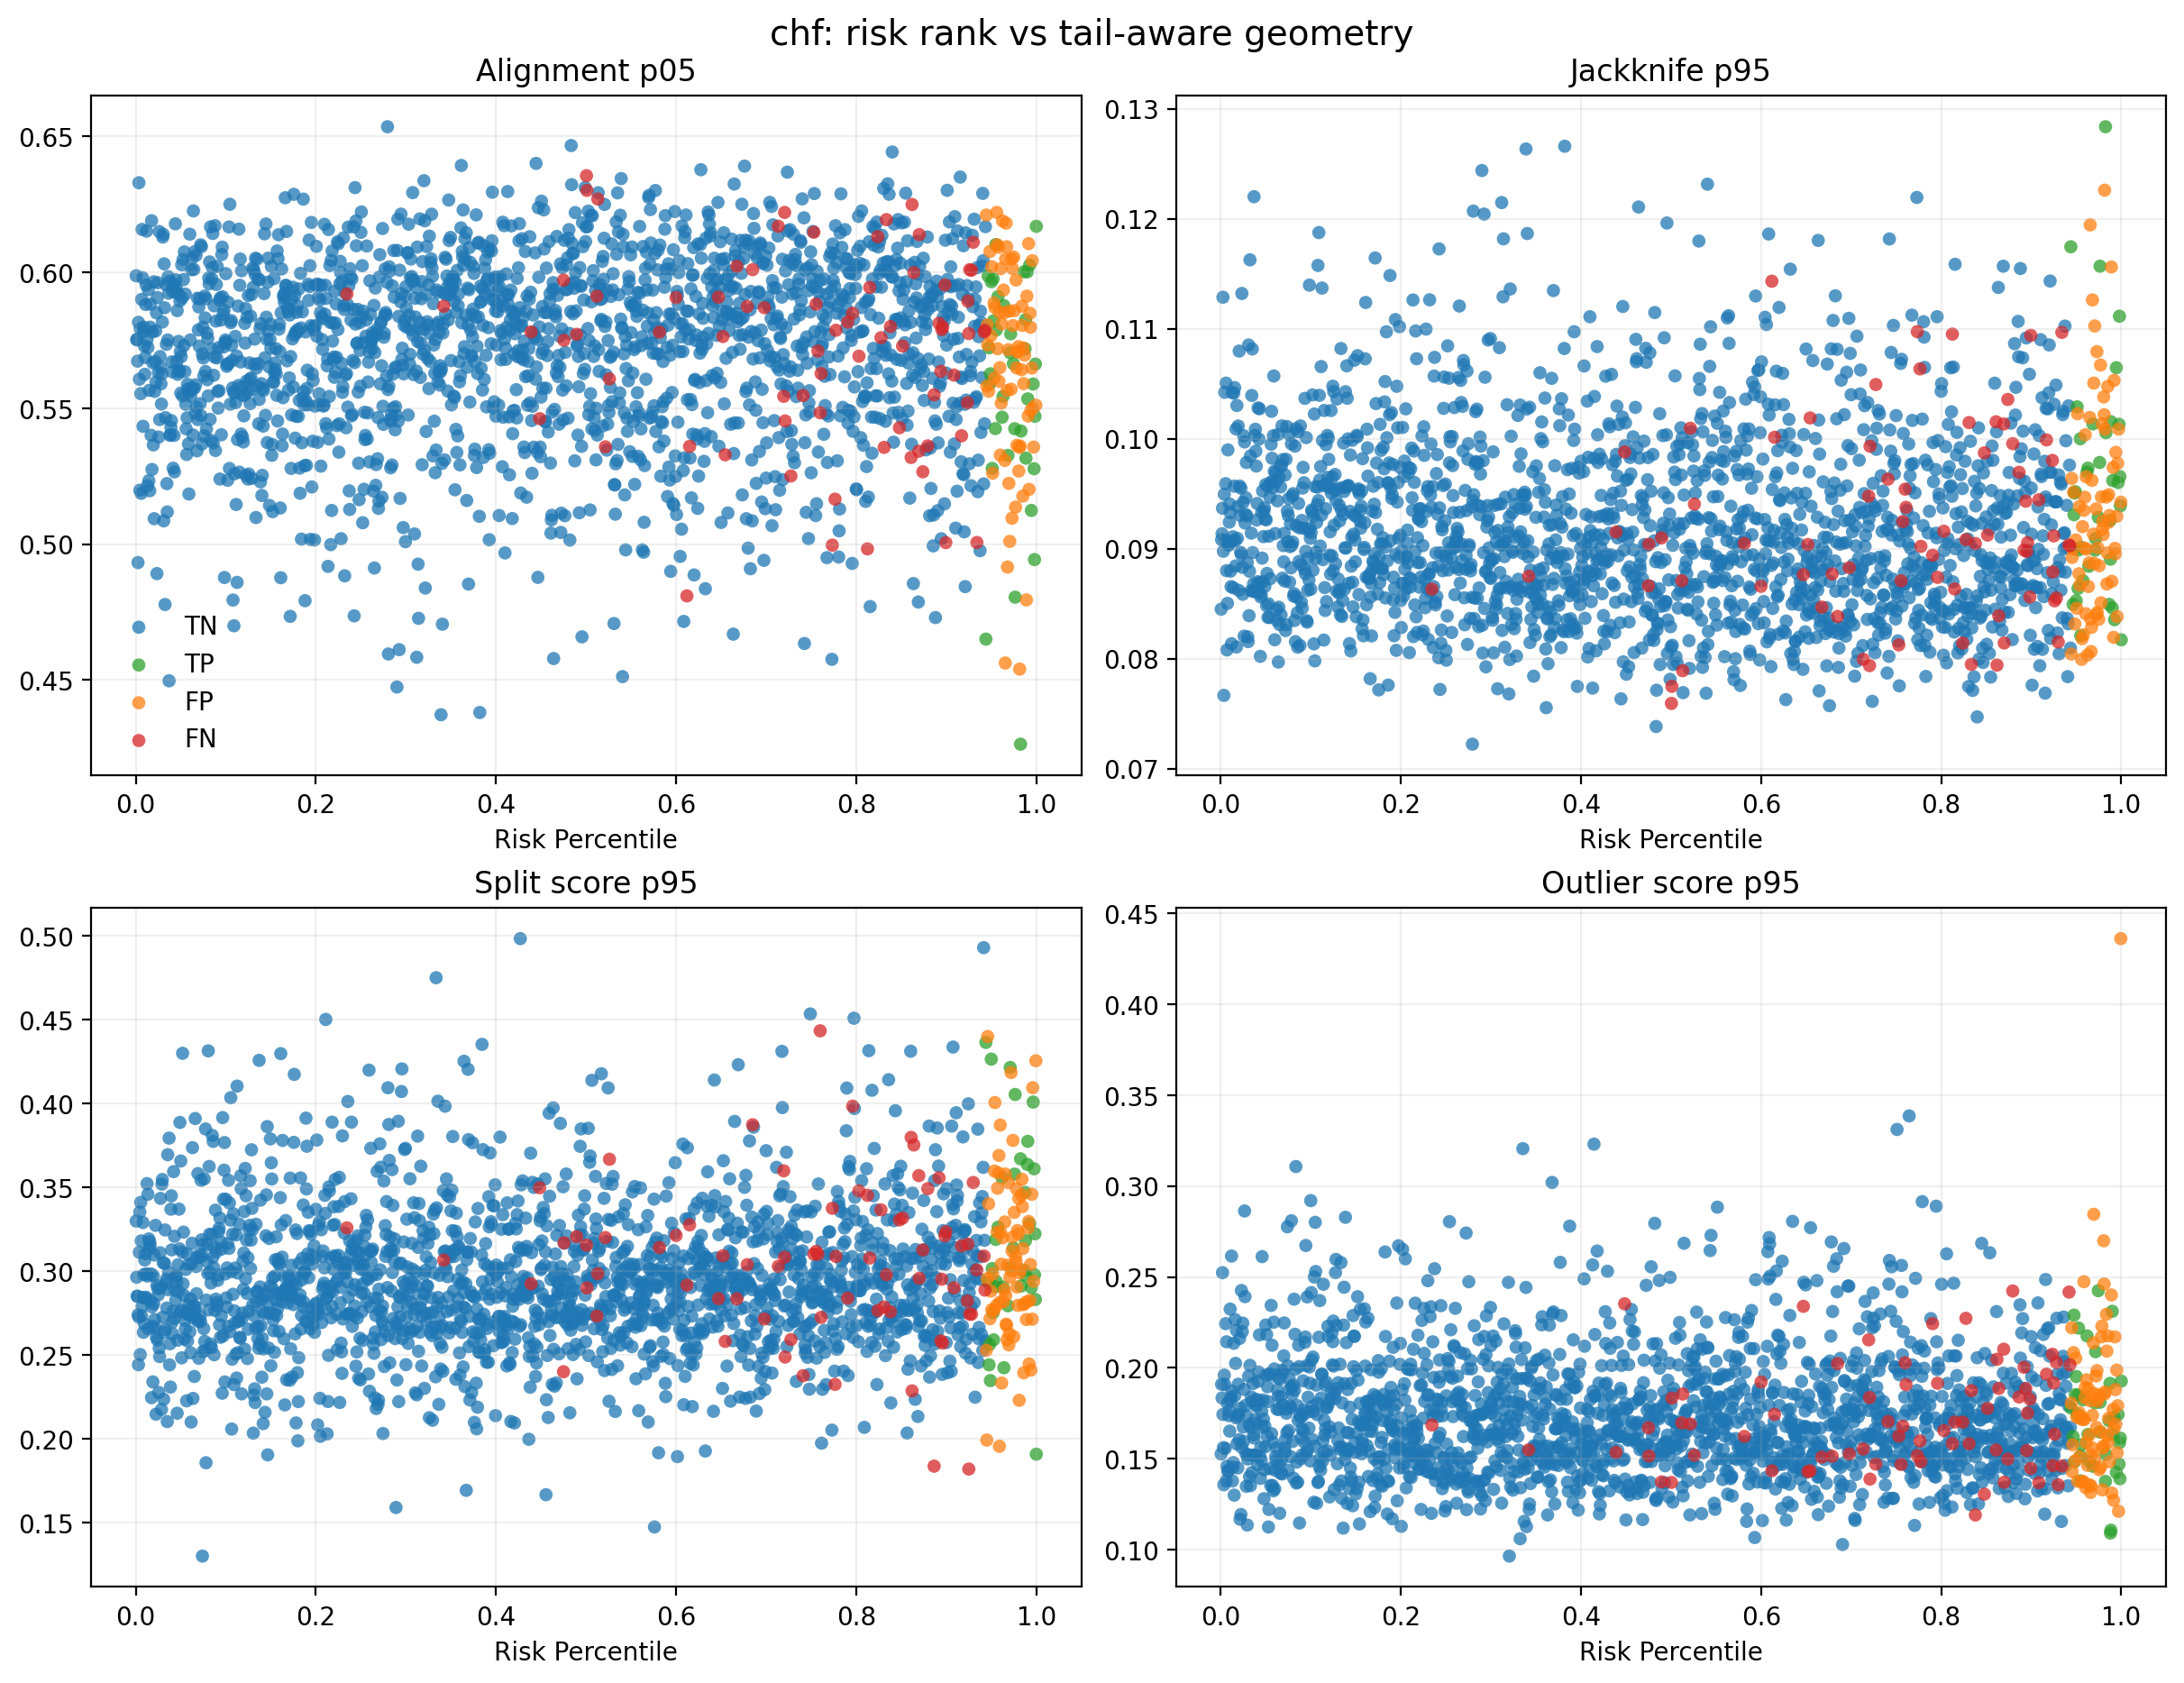

In [11]:
show_image('tail_boxplots', width=1100)
show_image('tail_risk_scatter', width=1100)


### tail-aware figure 해석

이 두 그림에서 읽을 포인트는 아래다.

- `split score p95`는 mean metric보다 `TP/FP`를 `TN`보다 위로 올려 주는 경향이 더 잘 보인다.
- `unstable tail`은 분명히 보이지만, risk rank와 거의 1대1로 겹치지는 않는다.

즉 `geometry tail`은 존재하고, 일부 error type과는 맞물리지만, **subject 평균 risk만으로 환원되는 신호는 아니다.**


+
CHF 예측에서 tail-aware geometry metric 중 split_score_p95가 가장 유망한 구조적 신호로 보인다. 이 신호는 TN에 비해 TP/FP/FN에서 약간 높은 경향을 보이며, high-risk subject에서도 상대적으로 살아 있지만, 전체 risk rank나 error type을 단독으로 설명할 정도로 강하지는 않다. 따라서 LOO-CL latent의 구조적 tail은 존재하며, 일부 예측 결과와 연관될 가능성이 있으나, long-horizon 질환 예측 오류를 충분히 설명하려면 추가적인 시간 정보와 중요 구간 분석이 필요하다.

## 8. figure 읽기: split vs outlier scatter와 constellation

다음으로는 이번 단계의 구조적 해석에 가장 중요한 그림 두 장을 본다.

- `chf_split_vs_outlier_6y.png`
  - `2+2 split`과 `3+1 outlier` tail이 같은 subject에서 어떻게 함께 나타나는지
- `chf_example_constellations.png`
  - stable / unstable example이 실제 latent 좌표와 pairwise cosine에서 어떻게 다른지


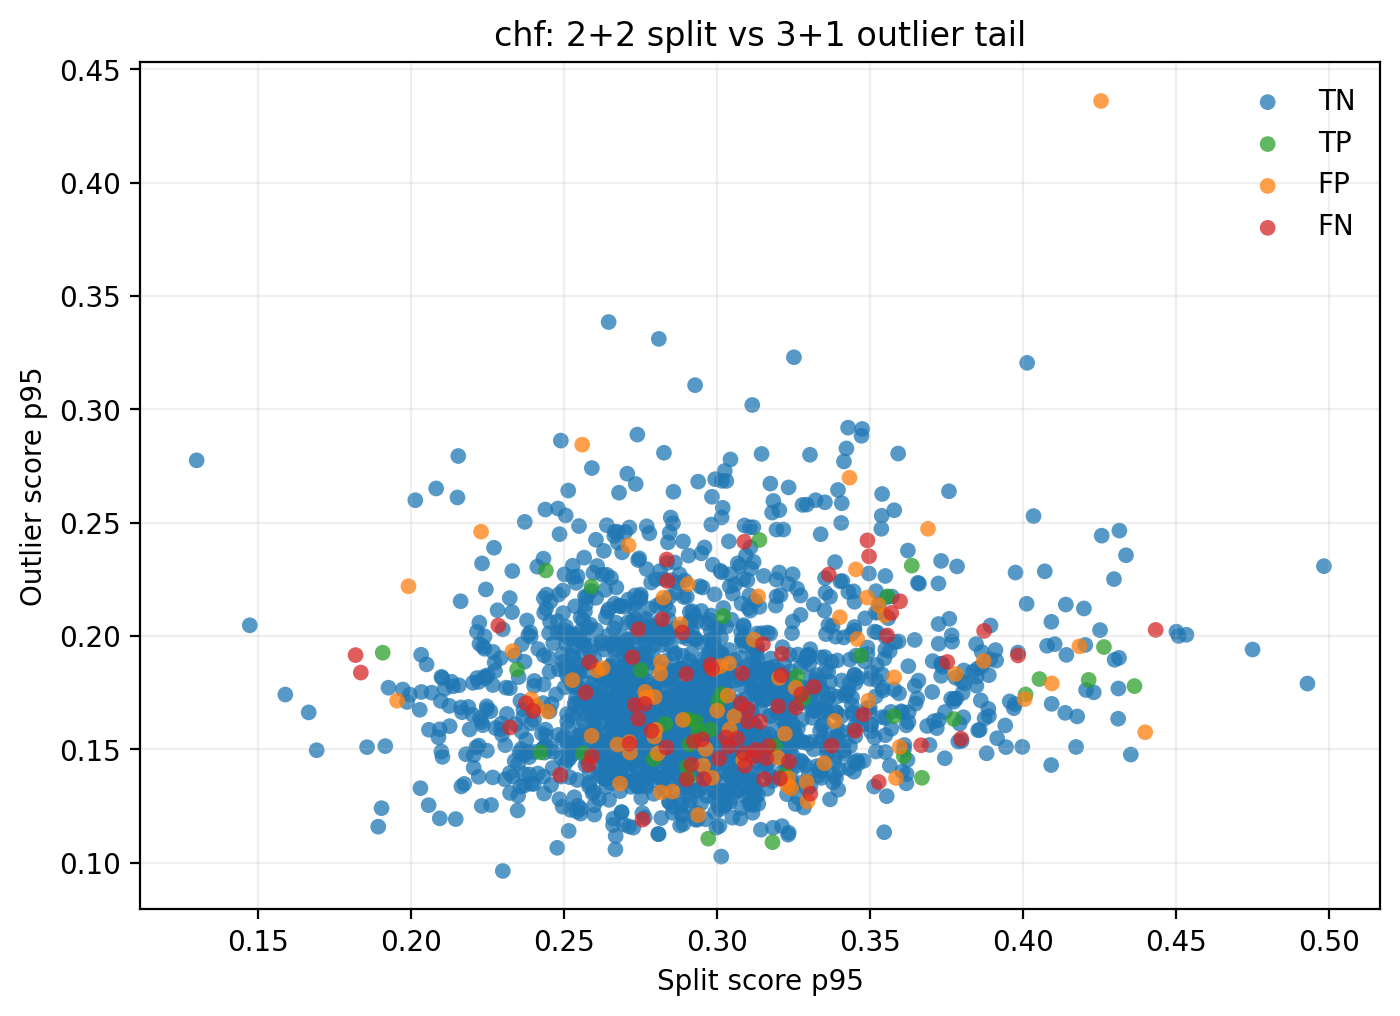

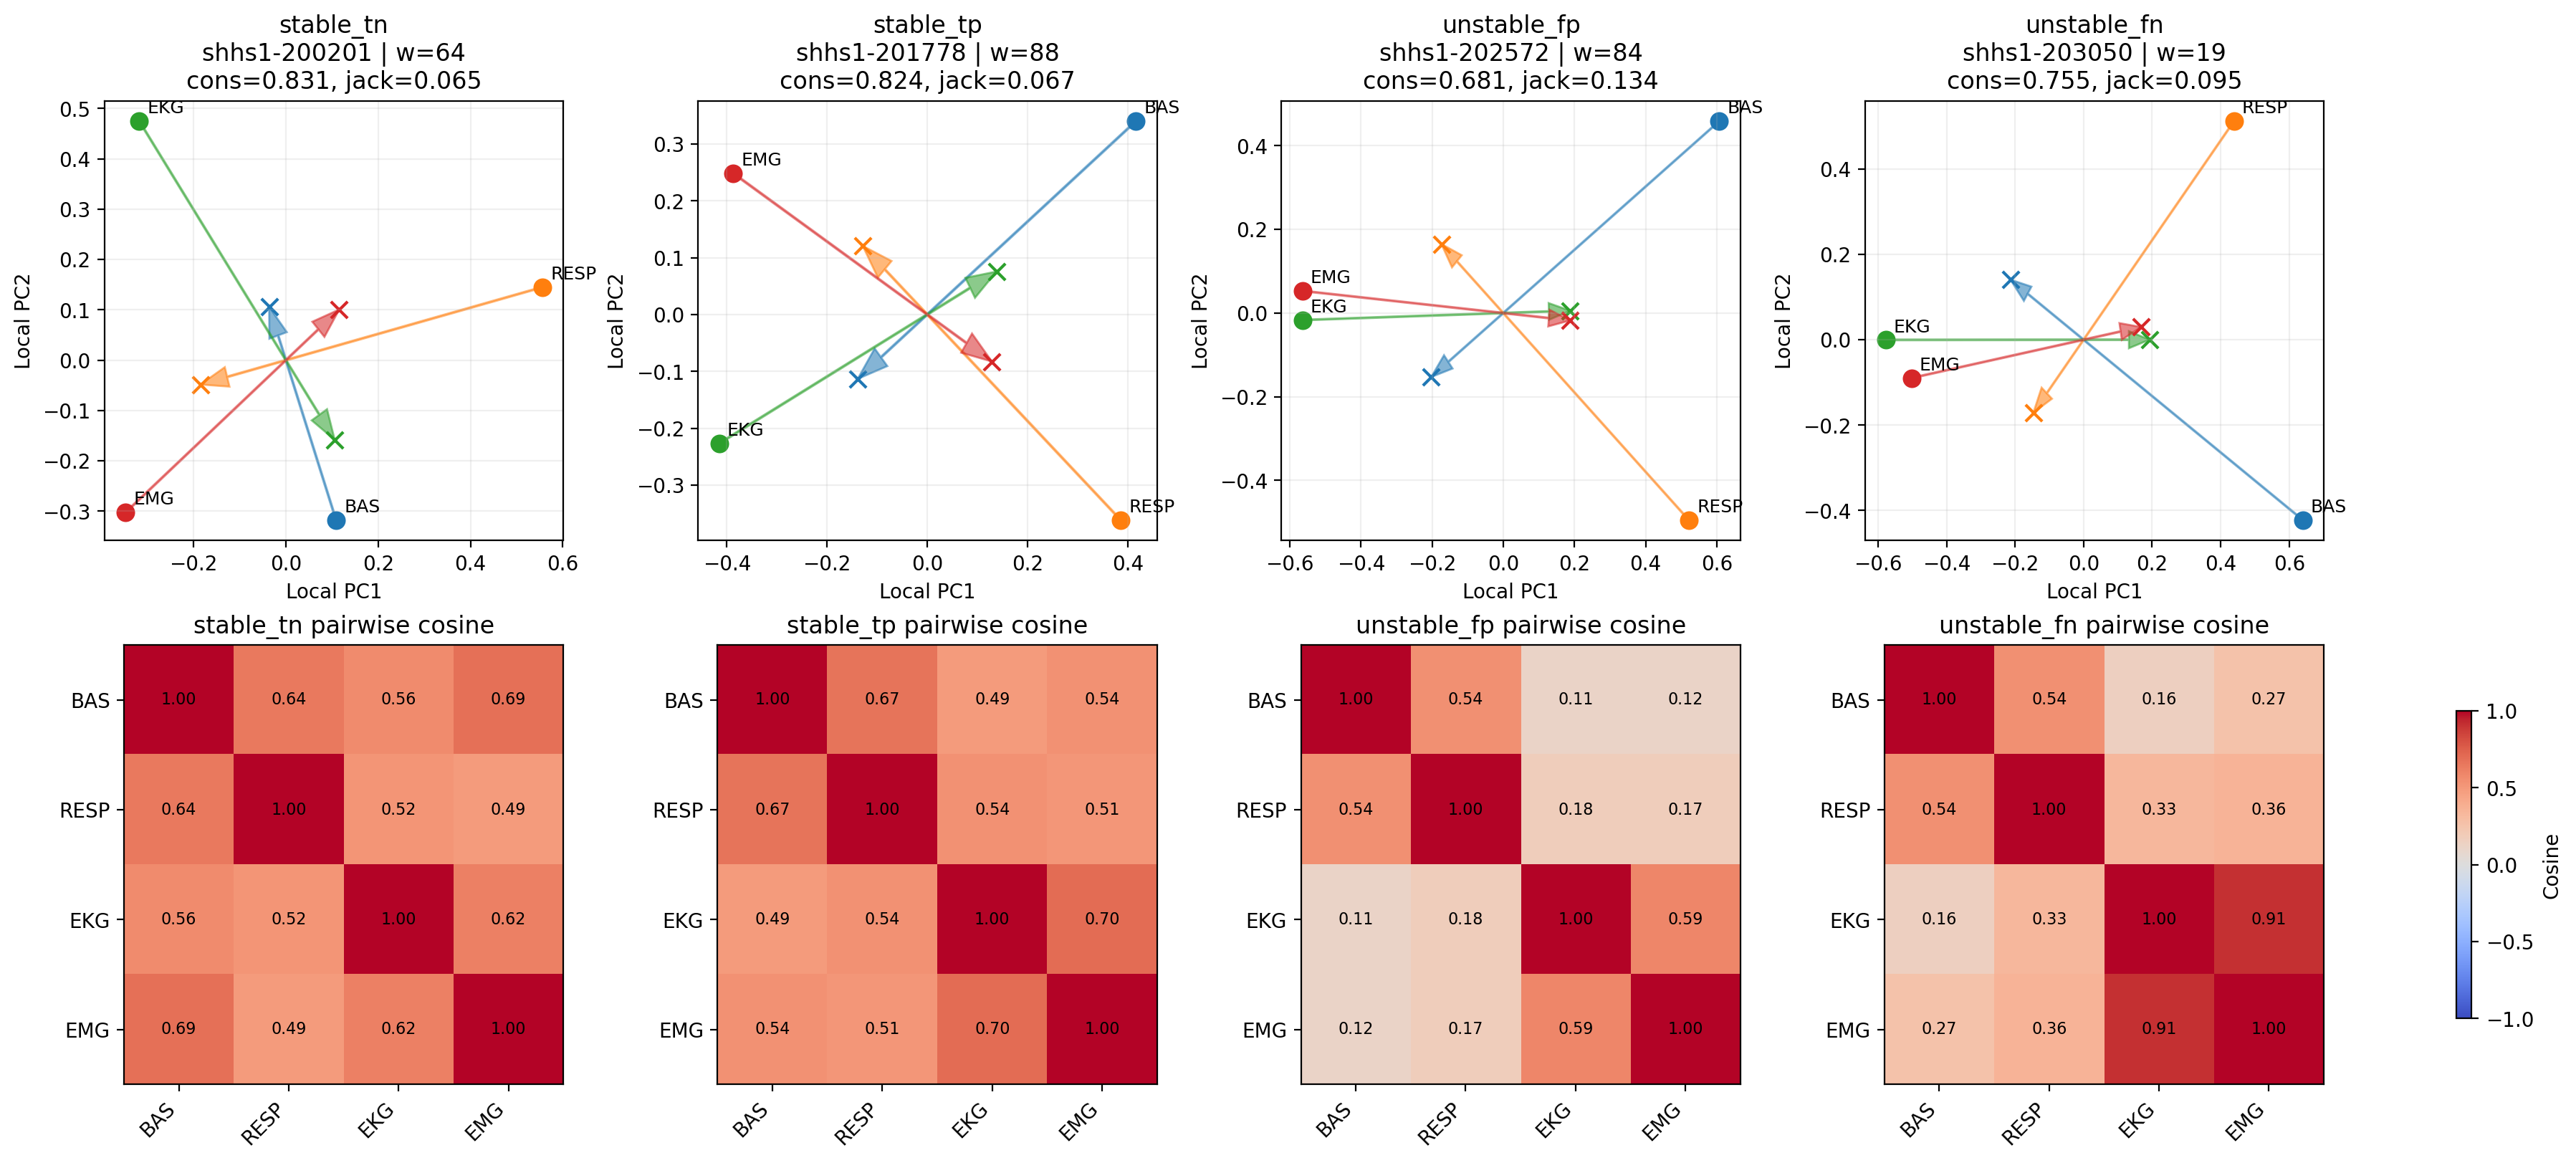

In [12]:
show_image('split_outlier_scatter', width=900)
show_image('constellations', width=1400)


### constellation 해석

이 그림은 이번 단계 전체의 구조를 가장 직관적으로 보여 준다.

- stable case
  - modality pairwise cosine이 전반적으로 높고, 각 modality가 자기 LOO mean 쪽으로 무난하게 이동한다.
- unstable case
  - `BAS/RESP`와 `EKG/EMG`가 갈라지거나, 특정 modality가 다른 3개와 어긋난다.
  - 이때 LOO mean은 깔끔한 consensus target이라기보다 compromise 방향으로 보인다.

즉 이번 단계는 문서에서 말한 `2+2 split`, `3+1 outlier`, `compromise target`을 case study 수준이 아니라 **새 지표와 전체 분포 위에서 다시 지지해 주는 단계**다.


## 9. 이번 단계에서 말할 수 있는 것

이번 단계 결과는 아래처럼 정리하는 것이 가장 정확하다.

### 이번 단계가 더 강하게 보여주는 것

- 전체 SHHS latent에서 `BAS+RESP | EKG+EMG`형 `2+2 split`이 실제로 지배적인 split 방향이다.
- `BAS`와 `EKG`가 상대적으로 outlier modality로 자주 잡힌다.
- `split_score_p95`와 `unstable_window_fraction`은 여러 target에서 `FP/TP`를 `TN`보다 더 unstable한 쪽으로 밀어 준다.

### 이번 단계에서도 아직 남는 것

- correlation은 여전히 작아서, subject-level summary만으로 long-horizon error를 충분히 설명하지는 못한다.
- 특히 `FN`은 항상 같은 방향으로 움직이지 않으므로, prediction-critical segment와의 연결이 필요하다.

따라서 문서에서 제안한 다음 단계인 `window metadata`, `stage transition`, `event density`, `prediction-critical window` 분석으로 넘어가는 것이 자연스럽다.


## 10. 이번 분석을 다시 실행하는 명령

아래 명령은 이번 단계 결과를 다시 만드는 최소 실행 경로다.


In [ ]:
rerun = r'''
cd C:/Projects/aiot/sleepfm-repro

python scripts/analyze_loo_geometry.py ^
  --embeddings-dir C:/Projects/aiot/sleepfm-repro/artifacts/embeddings/model_base_paperexact/shhs_5min_agg ^
  --output-dir C:/Projects/aiot/sleepfm-repro/artifacts/audit/loo_geometry_model_base_paperexact_shhs

python scripts/make_loo_diagnosis_figures.py ^
  --geometry-dir C:/Projects/aiot/sleepfm-repro/artifacts/audit/loo_geometry_model_base_paperexact_shhs ^
  --embedding-dir C:/Projects/aiot/sleepfm-repro/artifacts/embeddings/model_base_paperexact/shhs_5min_agg ^
  --eval-dir C:/Projects/aiot/sleepfm-repro/artifacts/embeddings/model_base_paperexact/DiagnosisFinetuneFullLSTMCOXPHWithDemo_shhs_shhs_6cvd_paperexact_3291_496_2000_demo_labels_BAS_RESP_EKG_EMG__ep_5_bs_8/shhs_downstream_paperlike_3291_496_2000/test ^
  --labels-dir C:/Projects/aiot/sleepfm-repro/artifacts/labels/shhs_6cvd_paperexact_3291_496_2000 ^
  --output-dir C:/Projects/aiot/sleepfm-repro/artifacts/audit/loo_geometry_model_base_paperexact_shhs/diagnosis_6y ^
  --focus-target chf
'''

display(Markdown('```powershell\n' + rerun.strip() + '\n```'))
